# Crimes Data from 2020 to present

## Introduction:

This dataset contains detailed records of crimes reported across various regions from 2020 to the present. It provides valuable insights into crime trends, patterns, and changes in crime rates over time.

## Problem Scenario:
I was assigned by a tourist company to undergo an analysis of the crime activities occurring over Los Angeles, as they would like to monitor safety concerns and adjust their routes throughout the city. As in the recent years, crime has declined since 2023 and they would like to identify which locations and areas would be a lot safer for new visitors.

## Objectives:

1 - Identify the most common crimes reported in Los Angeles.

2 - Examine how crime varies by time, including month, day, and time of day.

3 - Analyse victim demographics across crimes reported.

4 - Determine which areas experience the highest number of reported crimes.

5 - Status of the crime when it was commited

6 - Weapons reported used during the crime

7 - Investigate where and when fewer crimes are most frequently reported.

8 - Deeper Analysis


## Exploratory Data Analysis (EDA):

#### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
crimes_df = pd.read_csv('../../data/Crime_Data_from_2020_to_Present.csv')

In [3]:
crimes_df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1005194,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1005195,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,...,IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1005196,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922


In [4]:
crimes_df.head(5)

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [5]:
crimes_df.shape

(1005198, 28)

In [6]:
crimes_df.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='str')

In [7]:
crimes_df.dtypes

DR_NO               int64
Date Rptd             str
DATE OCC              str
TIME OCC            int64
AREA                int64
AREA NAME             str
Rpt Dist No         int64
Part 1-2            int64
Crm Cd              int64
Crm Cd Desc           str
Mocodes               str
Vict Age            int64
Vict Sex              str
Vict Descent          str
Premis Cd         float64
Premis Desc           str
Weapon Used Cd    float64
Weapon Desc           str
Status                str
Status Desc           str
Crm Cd 1          float64
Crm Cd 2          float64
Crm Cd 3          float64
Crm Cd 4          float64
LOCATION              str
Cross Street          str
LAT               float64
LON               float64
dtype: object

In [8]:
crimes_df.describe()

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


In [9]:
crimes_df.isnull().mean() * 100

DR_NO              0.000000
Date Rptd          0.000000
DATE OCC           0.000000
TIME OCC           0.000000
AREA               0.000000
AREA NAME          0.000000
Rpt Dist No        0.000000
Part 1-2           0.000000
Crm Cd             0.000000
Crm Cd Desc        0.000000
Mocodes           15.097523
Vict Age           0.000000
Vict Sex          14.403331
Vict Descent      14.404525
Premis Cd          0.001592
Premis Desc        0.058496
Weapon Used Cd    67.441240
Weapon Desc       67.441240
Status             0.000099
Status Desc        0.000000
Crm Cd 1           0.001094
Crm Cd 2          93.119863
Crm Cd 3          99.769797
Crm Cd 4          99.993633
LOCATION           0.000000
Cross Street      84.655461
LAT                0.000000
LON                0.000000
dtype: float64

In [10]:
crimes_df.duplicated().sum()
#theres no duplicates

np.int64(0)

## Data Handling:

### _Cleaning, transforming, and combining data_

In [11]:
crimes_df.columns = crimes_df.columns.str.lower().str.replace(" ","_")

In [12]:
crimes_df['date_rptd'] = pd.to_datetime(crimes_df['date_rptd'])
crimes_df['date_occ'] = pd.to_datetime(crimes_df['date_occ'])
crimes_df.dtypes

dr_no                      int64
date_rptd         datetime64[us]
date_occ          datetime64[us]
time_occ                   int64
area                       int64
area_name                    str
rpt_dist_no                int64
part_1-2                   int64
crm_cd                     int64
crm_cd_desc                  str
mocodes                      str
vict_age                   int64
vict_sex                     str
vict_descent                 str
premis_cd                float64
premis_desc                  str
weapon_used_cd           float64
weapon_desc                  str
status                       str
status_desc                  str
crm_cd_1                 float64
crm_cd_2                 float64
crm_cd_3                 float64
crm_cd_4                 float64
location                     str
cross_street                 str
lat                      float64
lon                      float64
dtype: object

In [13]:
#most null values in these columns, 99%
new_crime_df = crimes_df.drop(columns=['crm_cd_4', 'crm_cd_3'])

In [14]:
new_crime_df['area_name'].unique()

<StringArray>
[   'Wilshire',     'Central',   'Southwest',    'Van Nuys',  'Hollenbeck',
     'Rampart',      'Newton',   'Northeast', '77th Street',   'Hollywood',
      'Harbor', 'West Valley',     'West LA', 'N Hollywood',     'Pacific',
  'Devonshire',     'Mission',   'Southeast',     'Olympic',    'Foothill',
     'Topanga']
Length: 21, dtype: str

In [15]:
new_crime_df['crm_cd_desc'].unique()

<StringArray>
[                                        'VEHICLE - STOLEN',
                                    'BURGLARY FROM VEHICLE',
                                            'BIKE - STOLEN',
                 'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)',
                                                    'ARSON',
                                                 'BURGLARY',
                                                  'PIMPING',
                                                'PANDERING',
                                'OTHER MISCELLANEOUS CRIME',
                 'VANDALISM - MISDEAMEANOR ($399 OR UNDER)',
 ...
 'BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM',
                                                   'BIGAMY',
                                      'FAILURE TO DISPERSE',
       'FIREARMS EMERGENCY PROTECTIVE ORDER (FIREARMS EPO)',
             'INCEST (SEXUAL ACTS BETWEEN BLOOD RELATIVES)',
                           'BLOCKING DOOR INDUCTION CENTER',
     

In [16]:
new_crime_df['premis_desc'].unique()

<StringArray>
[                                        'STREET',
              'BUS STOP/LAYOVER (ALSO QUERY 124)',
   'MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)',
                                 'CLOTHING STORE',
                                 'PUBLIC STORAGE',
                                  'JEWELRY STORE',
                                 'OTHER BUSINESS',
                                    'PARKING LOT',
                                          'ALLEY',
                                    'GAS STATION',
 ...
                    'MTA - ORANGE LINE - DE SOTO',
          'TRAM/STREETCAR(BOXLIKE WAG ON RAILS)*',
       'RETIRED (DUPLICATE) DO NOT USE THIS CODE',
           'CHEMICAL STORAGE/MANUFACTURING PLANT',
     'MTA - SILVER LINE - LAC/USC MEDICAL CENTER',
                       'DEPT OF DEFENSE FACILITY',
 'TRAIN, OTHER THAN MTA (ALSO QUERY 809/810/811)',
                         'HOCKEY RINK/ICE HOCKEY',
                 'MTA - SILVER LINE - MANCHESTER',
        'HAR

In [17]:
new_crime_df['status_desc'].unique()

<StringArray>
['Adult Arrest', 'Invest Cont', 'Adult Other', 'Juv Arrest', 'Juv Other',
 'UNK']
Length: 6, dtype: str

In [18]:
new_crime_df['vict_sex'].unique()

<StringArray>
['M', 'X', nan, 'F', 'H', '-']
Length: 6, dtype: str

In [19]:
new_crime_df['vict_sex'] = new_crime_df['vict_sex'].replace(['X', 'H', '-'], "unknown")

In [20]:
new_crime_df['vict_sex'] = new_crime_df['vict_sex'].fillna("unknown")

In [21]:
new_crime_df['vict_sex'].unique()

<StringArray>
['M', 'unknown', 'F']
Length: 3, dtype: str

In [22]:
new_crime_df['weapon_desc'].unique()

<StringArray>
[                                             nan,
 'STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)',
                                  'VERBAL THREAT',
       'KNIFE WITH BLADE OVER 6 INCHES IN LENGTH',
                    'UNKNOWN WEAPON/OTHER WEAPON',
                                        'MACHETE',
                                       'HAND GUN',
                          'SEMI-AUTOMATIC PISTOL',
                                  'SIMULATED GUN',
                                         'HAMMER',
                                          'RAZOR',
                                  'OTHER FIREARM',
                                  'KITCHEN KNIFE',
                                          'STICK',
                                'UNKNOWN FIREARM',
               'KNIFE WITH BLADE 6INCHES OR LESS',
                                'PIPE/METAL PIPE',
               'AIR PISTOL/REVOLVER/RIFLE/BB GUN',
                       'OTHER CUTTING INSTRUMENT',
                 

### Creating new columns

In [23]:
new_crime_df['crime_day'] = pd.to_datetime(new_crime_df['date_occ']).dt.day

In [24]:
new_crime_df['crime_month'] = pd.to_datetime(new_crime_df['date_occ']).dt.month

In [25]:
new_crime_df['crime_year'] = pd.to_datetime(new_crime_df['date_occ']).dt.year

In [26]:
new_crime_df['crime_week'] = pd.to_datetime(new_crime_df['date_occ']).dt.day_name()

In [27]:
new_crime_df['crime_hour'] = new_crime_df['time_occ'] // 100

In [28]:
def time_category(hour):
    if hour < 12:
        return "Morning"
    elif hour < 16:
        return "Afternoon"
    elif hour < 21:
        return "Evening"
    else:
        return "Night"

new_crime_df['crime_time_day'] = new_crime_df['crime_hour'].apply(time_category)

In [29]:
def age_generation(year):
    if year <= 1945:
        return "Silent Generation"
    elif year <= 1964:
        return "Baby Boomers"
    elif year <= 1980:
        return "Gen X"
    elif year <= 1996:
        return "Millennials"
    elif year <= 2012:
        return "Gen Z"
    elif year <= 2024:
        return "Gen Alpha"
    else:
        return "Gen Beta"

In [30]:
new_crime_df['vict_year'] = new_crime_df['crime_year'] - new_crime_df['vict_age']

In [31]:
new_crime_df['vict_age_gen'] = new_crime_df['vict_year'].apply(age_generation)

In [32]:
new_crime_df['updated_location'] = new_crime_df['location'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [33]:
new_crime_df['updated_cross_street'] = new_crime_df['cross_street'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [34]:
new_crime_df

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,part_1-2,crm_cd,crm_cd_desc,...,crime_day,crime_month,crime_year,crime_week,crime_hour,crime_time_day,vict_year,vict_age_gen,updated_location,updated_cross_street
0,190326475,2020-03-01,2020-03-01,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,1,3,2020,Sunday,21,Night,2020,Gen Alpha,1900 S LONGWOOD AV,NaN
1,200106753,2020-02-09,2020-02-08,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,8,2,2020,Saturday,18,Evening,1973,Gen X,1000 S FLOWER ST,NaN
2,200320258,2020-11-11,2020-11-04,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,4,11,2020,Wednesday,17,Evening,2001,Gen Z,1400 W 37TH ST,NaN
3,200907217,2023-05-10,2020-03-10,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,10,3,2020,Tuesday,20,Evening,2001,Gen Z,14000 RIVERSIDE DR,NaN
4,200412582,2020-09-09,2020-09-09,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,...,9,9,2020,Wednesday,6,Morning,2020,Gen Alpha,200 E AVENUE 28,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1005193,250304214,2025-02-23,2025-02-21,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,...,21,2,2025,Friday,15,Afternoon,2025,Gen Beta,3600 MCCLINTOCK AV,NaN
1005194,250304203,2025-02-20,2025-02-13,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",...,13,2,2025,Thursday,21,Night,2025,Gen Beta,2600 ELLENDALE PL,NaN
1005195,250504051,2025-01-14,2025-01-14,1250,5,Harbor,509,1,210,ROBBERY,...,14,1,2025,Tuesday,12,Afternoon,2010,Gen Z,24300 WESTERN AV,NaN
1005196,251604136,2025-02-27,2025-02-27,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,...,27,2,2025,Thursday,15,Afternoon,2025,Gen Beta,11900 SHELDON ST,NaN


In [35]:
new_crime_df.dtypes

dr_no                            int64
date_rptd               datetime64[us]
date_occ                datetime64[us]
time_occ                         int64
area                             int64
area_name                          str
rpt_dist_no                      int64
part_1-2                         int64
crm_cd                           int64
crm_cd_desc                        str
mocodes                            str
vict_age                         int64
vict_sex                           str
vict_descent                       str
premis_cd                      float64
premis_desc                        str
weapon_used_cd                 float64
weapon_desc                        str
status                             str
status_desc                        str
crm_cd_1                       float64
crm_cd_2                       float64
location                           str
cross_street                       str
lat                            float64
lon                      

In [36]:
new_crime_df.to_csv('../../data/updatedCrimes.csv', index=False)

In [37]:
new_crime_df.duplicated().sum()

np.int64(0)

## Analysis:

#### Answering the objectives through data analysis

In [38]:
new_crime_df['crm_cd_desc'].value_counts().head(10)

crm_cd_desc
VEHICLE - STOLEN                                           115247
BATTERY - SIMPLE ASSAULT                                    74847
BURGLARY FROM VEHICLE                                       63518
THEFT OF IDENTITY                                           62539
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     61094
BURGLARY                                                    57879
THEFT PLAIN - PETTY ($950 & UNDER)                          53723
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              53532
INTIMATE PARTNER - SIMPLE ASSAULT                           46712
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             41316
Name: count, dtype: int64

In [39]:
new_crime_df['area_name'].value_counts().head(10)

area_name
Central        69674
77th Street    61763
Pacific        59520
Southwest      57511
Hollywood      52430
N Hollywood    51107
Olympic        50071
Southeast      49941
Newton         49181
Wilshire       48240
Name: count, dtype: int64

## Objective 1 - Identify the most common crimes reported in Los Angeles.

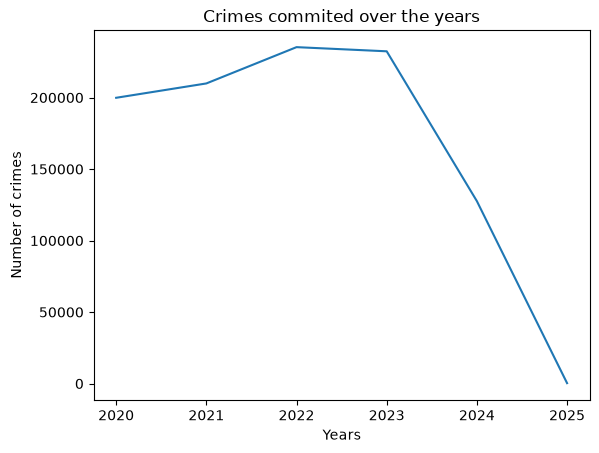

In [40]:
new_crime_df.groupby('crime_year').size().plot(kind='line', title='Crimes commited over the years', xlabel='Years', ylabel ='Number of crimes');

<Axes: title={'center': '10 of the most recorded crime'}, xlabel='Number of Crimes', ylabel='Description of the crime recorded'>

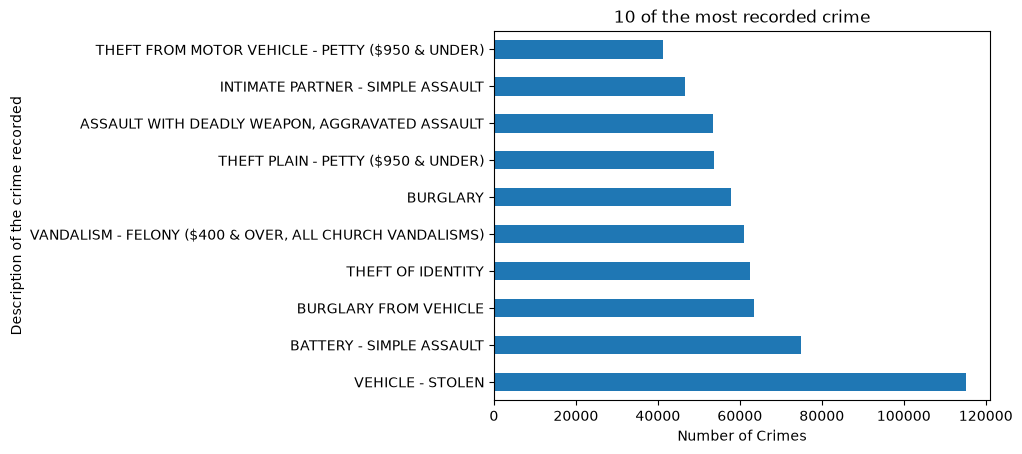

In [41]:
new_crime_df['crm_cd_desc'].value_counts().head(10).plot(kind='barh', title='10 of the most recorded crime', xlabel='Number of Crimes', ylabel='Description of the crime recorded')

## Objective 2 - Examine how crime varies by time, including month, day, and time of day.


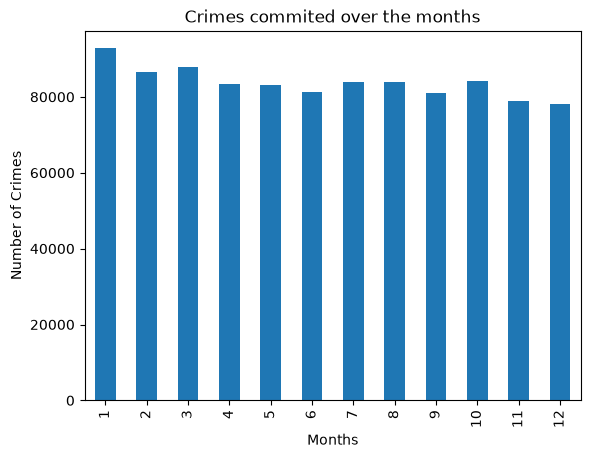

In [65]:
new_crime_df.groupby('crime_month').size().plot(kind='bar', title='Crimes commited over the months', xlabel='Months', ylabel='Number of Crimes');

In [79]:
new_crime_df['crime_month'].value_counts().sort_index()

crime_month
1     92776
2     86490
3     87859
4     83517
5     83014
6     81384
7     83962
8     83851
9     81016
10    84128
11    78977
12    78224
Name: count, dtype: int64

In [ ]:
new_crime_df['crime_month']

crime_month
1     92776
2     86490
3     87859
4     83517
5     83014
6     81384
7     83962
8     83851
9     81016
10    84128
11    78977
12    78224
Name: count, dtype: int64

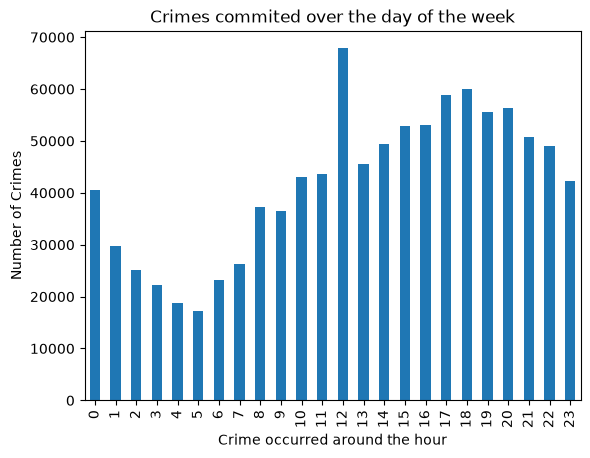

In [76]:
new_crime_df.groupby('crime_hour').size().plot(kind='bar', title='Crimes commited over the day of the week', xlabel='Crime occurred around the hour', ylabel='Number of Crimes');

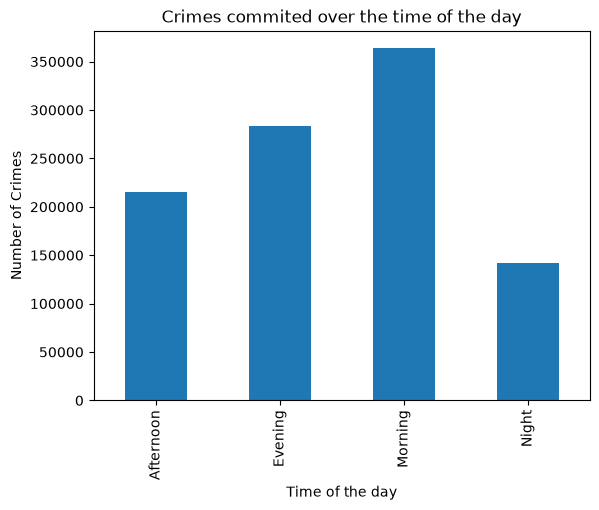

In [75]:
new_crime_df.groupby('crime_time_day').size().plot(kind='bar', title='Crimes commited over the time of the day', xlabel='Time of the day', ylabel='Number of Crimes');

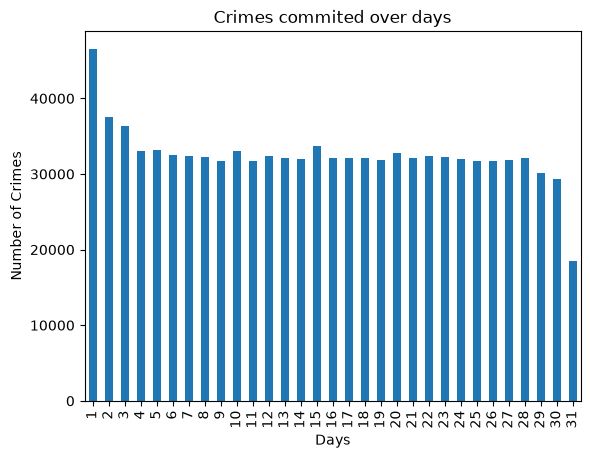

In [74]:
new_crime_df.groupby('crime_day').size().plot(kind='bar', title='Crimes commited over days', xlabel='Days', ylabel='Number of Crimes');

## Objective 3 - Analyse victim demographics across crimes reported.

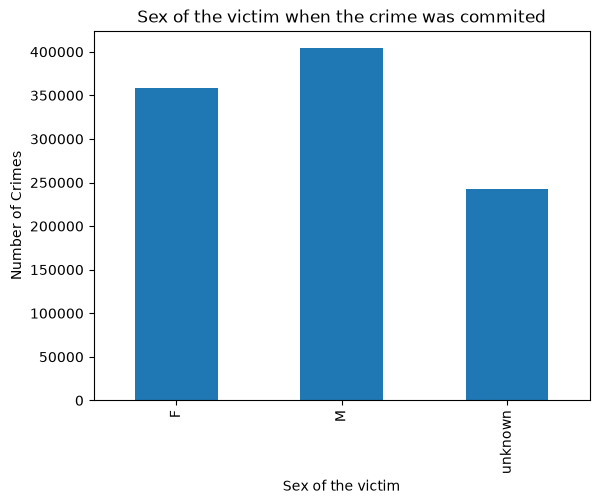

In [46]:
new_crime_df.groupby('vict_sex').size().plot(kind='bar', title='Sex of the victim when the crime was commited', xlabel='Sex of the victim', ylabel='Number of Crimes');

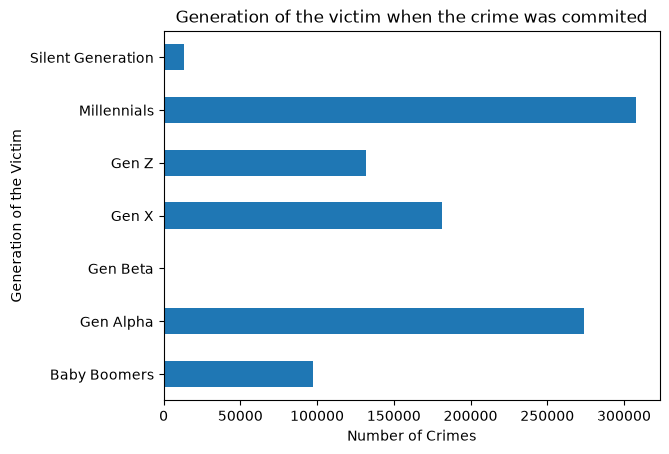

In [47]:
new_crime_df.groupby('vict_age_gen').size().plot(kind='barh', title='Generation of the victim when the crime was commited', xlabel='Number of Crimes', ylabel='Generation of the Victim');

## Objective 4 - Determine which areas experience the highest number of reported crimes.


<Axes: title={'center': 'most recorded crime by area'}, xlabel='Number of Crimes', ylabel='Area of the crime recorded'>

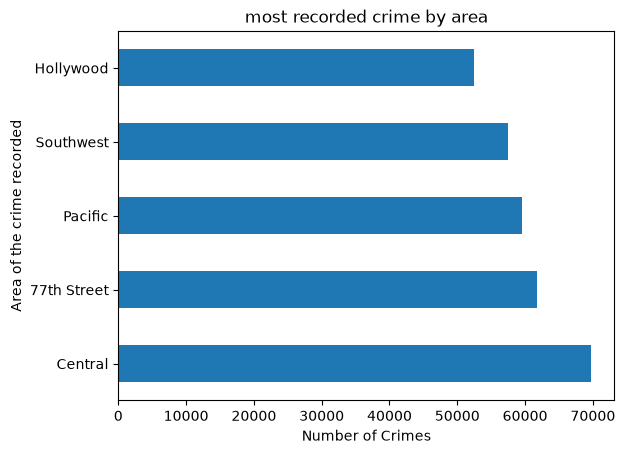

In [80]:
new_crime_df['area_name'].value_counts().head(5).plot(kind='barh', title='most recorded crime by area', xlabel='Number of Crimes', ylabel='Area of the crime recorded')

<Axes: title={'center': 'Most recorded crime by location'}, xlabel='Number of Crimes', ylabel='Location of the crime recorded'>

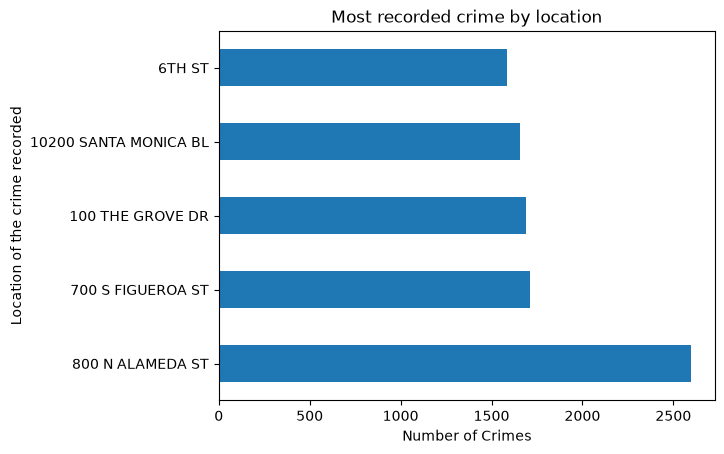

In [81]:
new_crime_df['updated_location'].value_counts().head(5).plot(kind='barh', title='Most recorded crime by location', xlabel='Number of Crimes', ylabel='Location of the crime recorded')

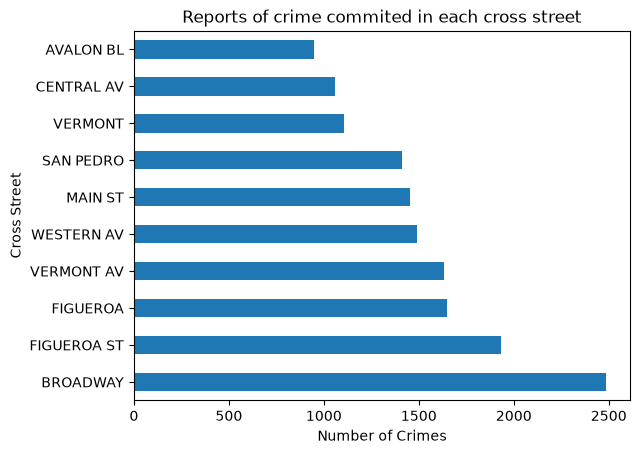

In [50]:
new_crime_df['updated_cross_street'].value_counts().head(10).plot(kind='barh', title='Reports of crime commited in each cross street', xlabel='Number of Crimes', ylabel='Cross Street');

## Objective 5 - Status of the crime when it was commited

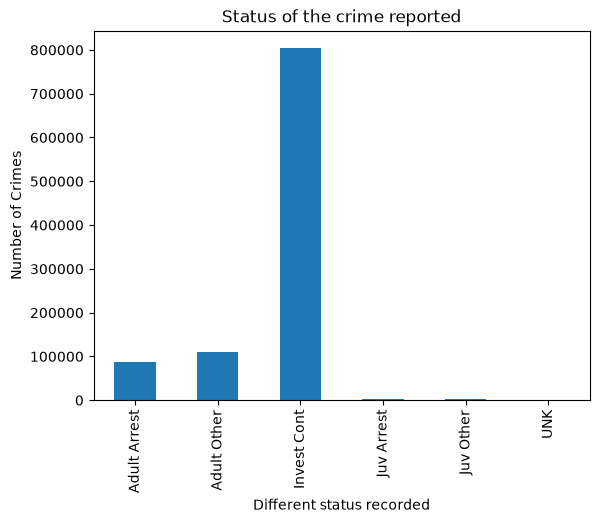

In [51]:
new_crime_df.groupby('status_desc').size().plot(kind='bar', title='Status of the crime reported', xlabel='Different status recorded', ylabel='Number of Crimes');

## Objective 6 - Weapons reported used during the crime

<Axes: title={'center': 'Threat recorded during the crime'}, xlabel='Number of Crimes', ylabel='Weapon used during the crime recorded'>

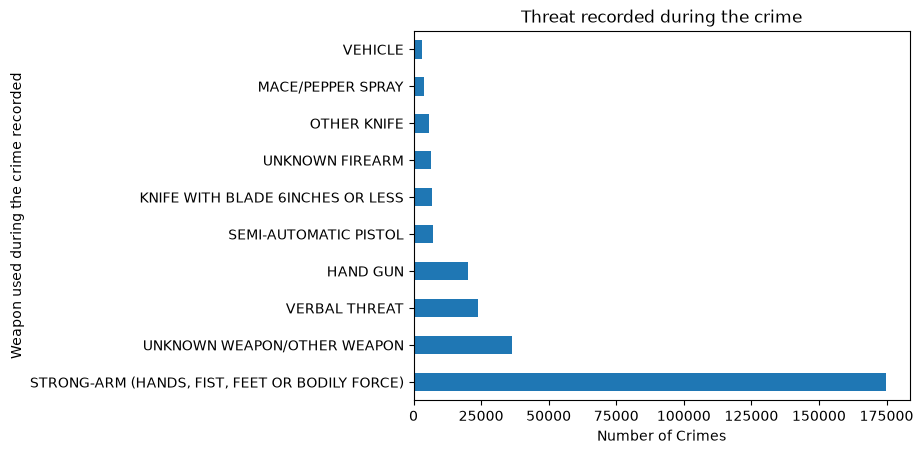

In [52]:
new_crime_df['weapon_desc'].value_counts().head(10).plot(kind='barh', title='Threat recorded during the crime', xlabel='Number of Crimes', ylabel='Weapon used during the crime recorded')

##  Objective 7 - Investigate where and when fewer crimes are most frequently reported.

<Axes: title={'center': 'Fewest Recorded Crimes by Area'}, xlabel='Number of Crimes', ylabel='Area of the Crime Recorded'>

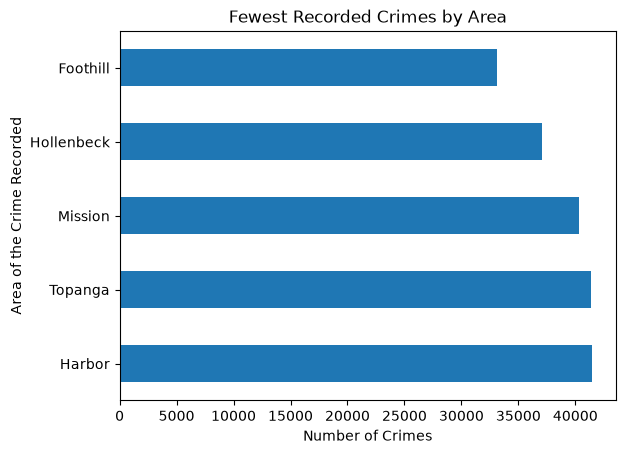

In [88]:
new_crime_df['area_name'].value_counts().tail(5).plot(kind='barh', title='Fewest Recorded Crimes by Area', xlabel='Number of Crimes', ylabel='Area of the Crime Recorded')

<Axes: title={'center': 'Fewest Recorded Crimes by Area'}, xlabel='Number of Crimes', ylabel='Area of the Crime Recorded'>

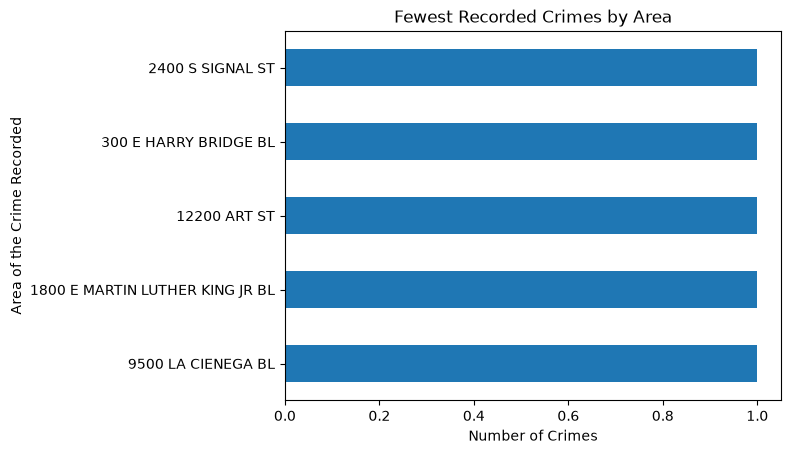

In [93]:
new_crime_df['updated_location'].value_counts().tail(5).plot(kind='barh', title='Fewest Recorded Crimes by Area', xlabel='Number of Crimes', ylabel='Area of the Crime Recorded')

<Axes: title={'center': 'Fewest Threats recorded during the crime'}, xlabel='Number of Crimes', ylabel='Weapon used during the crime recorded'>

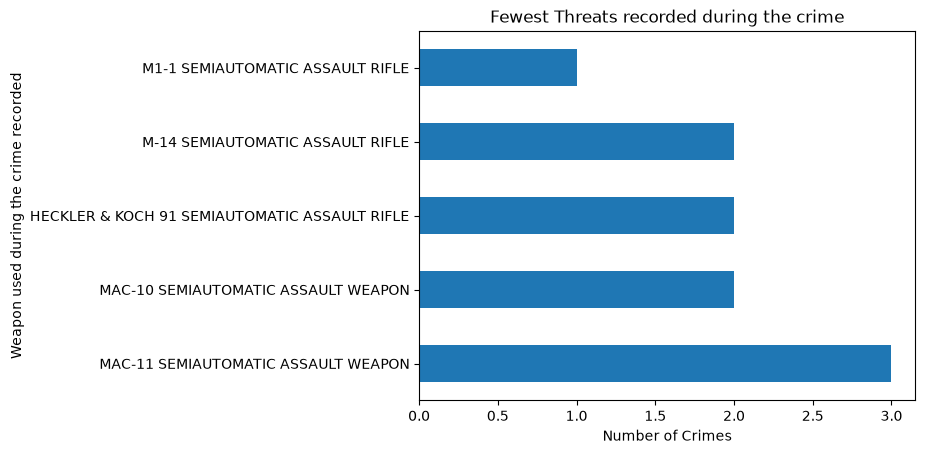

In [89]:
new_crime_df['weapon_desc'].value_counts().tail(5).plot(kind='barh', title='Fewest Threats recorded during the crime', xlabel='Number of Crimes', ylabel='Weapon used during the crime recorded')

<Axes: title={'center': 'Fewest Recorded Crimes by Description'}, xlabel='Number of Crimes', ylabel='Description of the Crime Recorded'>

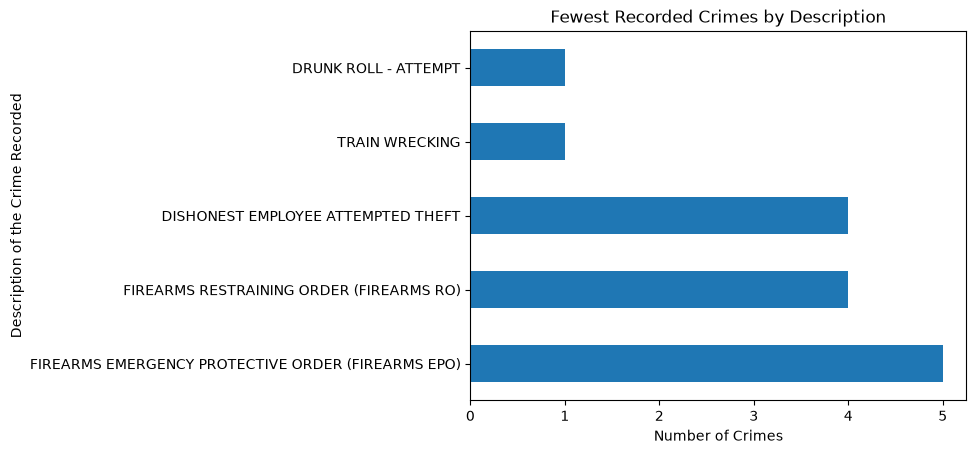

In [90]:
new_crime_df['crm_cd_desc'].value_counts().tail(5).plot(kind='barh', title='Fewest Recorded Crimes by Description', xlabel='Number of Crimes', ylabel='Description of the Crime Recorded')

<Axes: title={'center': 'Fewest recorded crimes by generation'}, xlabel='Number of Crimes', ylabel='Generation of the Victim'>

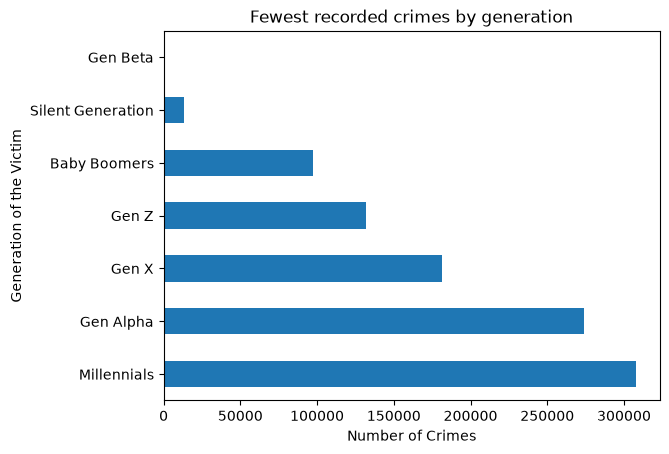

In [56]:
new_crime_df['vict_age_gen'].value_counts().tail(10).plot(kind='barh', title='Fewest recorded crimes by generation', xlabel='Number of Crimes', ylabel='Generation of the Victim')

## Deeper Analysis

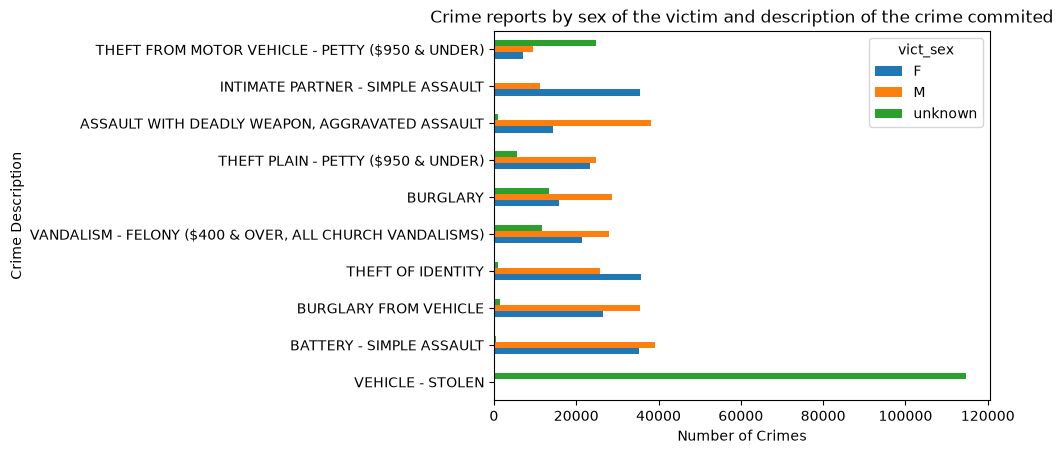

In [87]:
top_crimes = new_crime_df["crm_cd_desc"].value_counts().head(10).index
pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["vict_sex"]
).loc[top_crimes].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by sex of the victim and description of the crime commited');

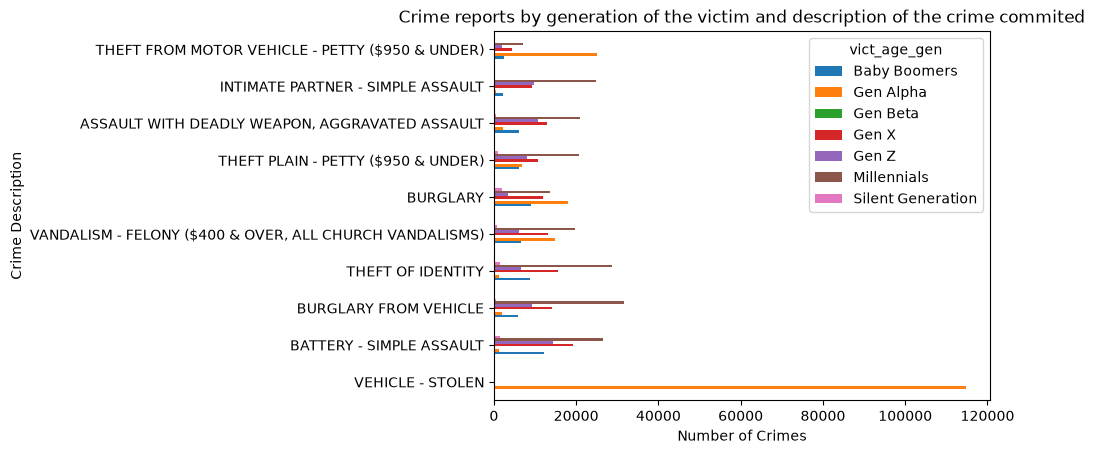

In [86]:
pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["vict_age_gen"]
).loc[top_crimes].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by generation of the victim and description of the crime commited');

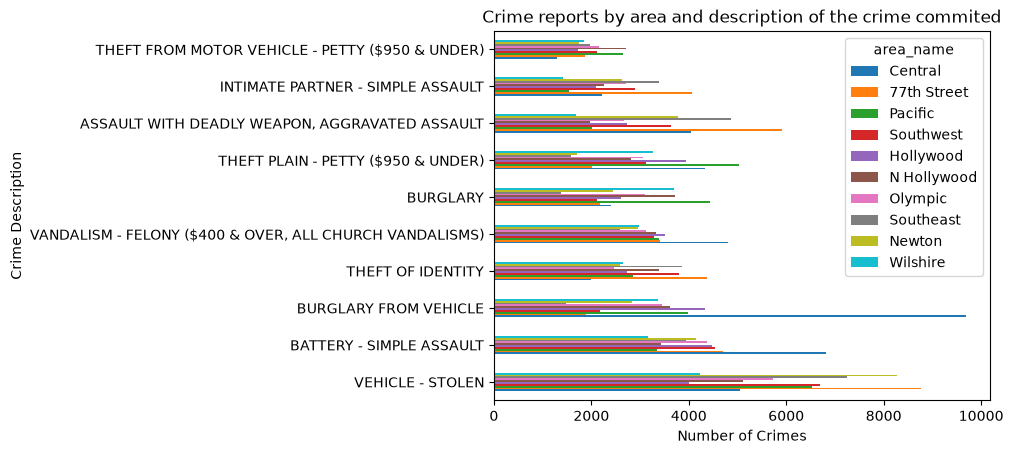

In [85]:
top_crimes = new_crime_df["crm_cd_desc"].value_counts().head(10).index
top_area = new_crime_df['area_name'].value_counts().head(10).index
pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["area_name"]
).loc[top_crimes, top_area].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by area and description of the crime commited');

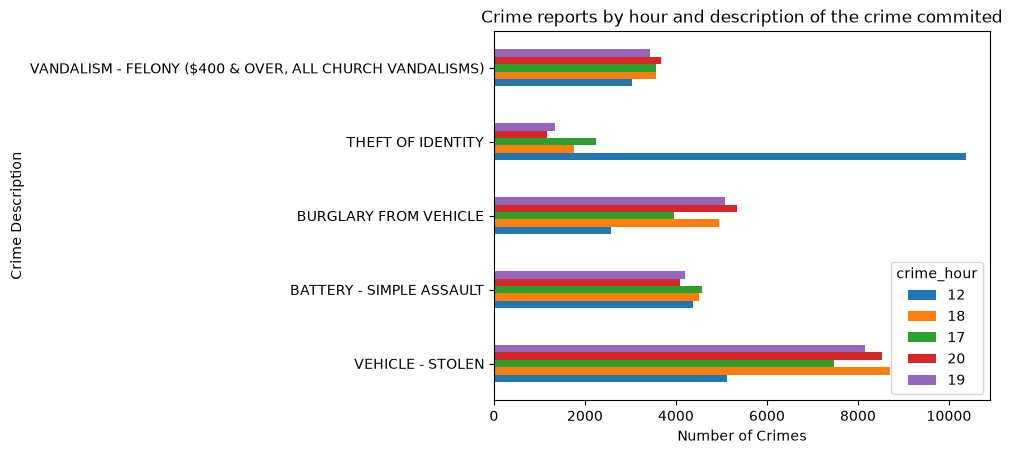

In [84]:
top_hour = new_crime_df['crime_hour'].value_counts().head(5).index

pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["crime_hour"]
).loc[top_crimes, top_hour].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by hour and description of the crime commited');

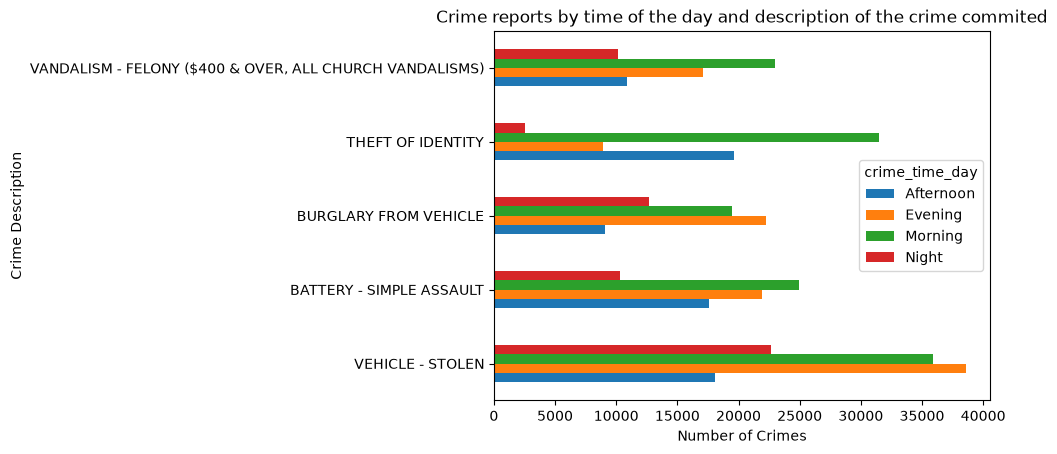

In [83]:
#what crimes are happening during the time of day
top_crimes = new_crime_df["crm_cd_desc"].value_counts().head(5).index
pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["crime_time_day"],
).loc[top_crimes].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by time of the day and description of the crime commited');

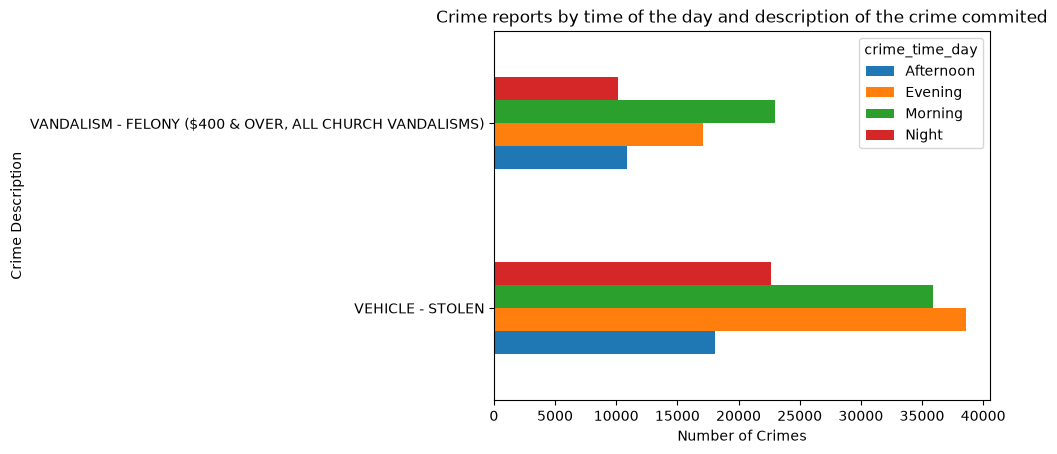

In [82]:
focus_crimes = ["VEHICLE - STOLEN", "VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)"]

top_crimes = new_crime_df["crm_cd_desc"].value_counts().head(5).index
pd.crosstab(
    new_crime_df["crm_cd_desc"],
    new_crime_df["crime_time_day"],
).loc[focus_crimes].plot(kind="barh", xlabel='Number of Crimes', ylabel='Crime Description', title='Crime reports by time of the day and description of the crime commited');

plt.show()

## Summary of my works

In this project, I was successfully able to analyse the crime data from Los Angeles to indetify patterns and trends that could help to identify the best route for tourists. Intially, I began with cleaning the data, finding null and missing values and converting columns like date occured into many different columns to expand my analysis. 

After completing the main stage, I began to work towards the exploratory data analysis (EDA), where I could investigate crime patterns based on factors such as by crime types, area, sex of the victtim, weapon used. Visualisations tools such as Matplotlib and Pandas made analysing the patterns more easier.

My analysis focused on identifying when and where crimes were occuring the most frequently and which types of crimes were occuring less. These findings could help to provide a clearer understanding of crime patterns from a tourism perspective as it requires careful planning for the saftey of the tourist. 

## Recommendations/Conclusion

Review datasets - As the dataset does not contain a full year of data for 2025, I recommend validating these findings with updated crime data before planning on final decisions.

Area and Location - Consider areas and locations such as Foothill and 2400 S Signal St, as they had some of the lowest reported crime levels in the dataset. 

Time of the day - Based on the dataset, Night had the fewest reported crimes. This could be considered when planning the timing of tourist activities and routes. 


In conclusion, I would the dataset is limited to my research as trends over violent criminals differ over time, based on their behavoir, reason and condition. Additionly, a more recent  dataset would be helpful. 
